# The Fabry-Perot Etalon
It is an optical cavity made from two parallel reflecting surfaces (i.e., thin mirrors). Optical waves can pass through the optical cavity only when they are in resonance with it.

<img src="fabry_perot_setup.png">

The cavity is defined by a propagation length $L$ in vacuum, amplitude reflectivities $r_1$ and $r_2$, and amplitude transmittivities $t_1$ and $t_2$ for the two mirrors. The optical field amplitudes at different points inside the cavity can be obtained through the superposition of reflected and transmitted fields.

The reflected field from the cavity is obtained as
$$
    \boxed{a_4=a_0\frac{r_1-r_2(r_1^2+t_1^2)e^{-i2kL}}{1-r_1 r_2 e^{-i2kL}}}
$$

while the transmitted field becomes

$$
\boxed{a_2=a_0\frac{-t_1 t_2 e^{-ikL}}{1-r_1 r_2 e^{-i2kL}}}
$$

The circulating optical power inside the cavity depends strongly on the laser frequency. Maximum intracavity power occurs when the denominator of the cavity response becomes minimum. This happens when the round-trip phase accumulated by the optical field is an integer multiple of $2\pi$. The resonance condition is therefore $2L = N\lambda$, where $N$ is an integer and $\lambda$ is the wavelength of the injected light.

Using the relation, $k=\frac{2\pi}{\lambda}$ the resonance condition can be rewritten as: 
$2L = \frac{N2\pi}{k} \implies \boxed{kL = N\pi}$

Minimum circulating power occurs at anti-resonance, where
$kL = \left(N+\frac{1}{2}\right)\pi$
corresponding to destructive interference between successive round-trip fields.

---
## Free Spectral Range

The phase accumulated during a round trip can also be written as: 
$2kL=\frac{\omega 2L}{c}=2\pi f \frac{2L}{c}=2\pi \frac{f}{\text{FSR}}$
where the quantity
$
\boxed{\text{FSR}=\frac{c}{2L}}
$
is called the **free spectral range** of the cavity. The free spectral range represents the frequency spacing between adjacent cavity resonances. Resonance therefore occurs at frequencies,
$
f_r = N\cdot \text{FSR}
$
with $N$ being an integer.

---
## Linewidth

Another important characteristic of the cavity is its linewidth, usually specified by its full width at half maximum (FWHM) or equivalently by the pole frequency $f_p$. The linewidth is determined by the frequency at which the circulating power falls to half of its maximum value. This yields the full linewidth expression

$$
\boxed{\text{FWHM}
=
2f_p
=
\frac{2\text{FSR}}{\pi}
\arcsin
\left(
\frac{1-r_1 r_2}{2\sqrt{r_1 r_2}}
\right)}
$$

---
## Finesse

The ratio of the free spectral range to the linewidth defines the cavity finesse:

$$
\boxed{\mathcal{F}
=
\frac{\text{FSR}}{\text{FWHM}}
=
\frac{\pi}{
2\arcsin
\left(
\frac{1-r_1 r_2}{2\sqrt{r_1 r_2}}
\right)
}}
$$

The finesse of a cavity is its quality factor. The finesse measures the sharpness of the cavity resonance peaks. High finesse cavities exhibit narrow resonances and large intracavity power buildup.

For highly reflective mirrors where $r_1 \approx 1$, and $r_2 \approx 1$, the argument of the arcsine function becomes small, allowing the approximation

$$
\mathcal{F}
\approx
\frac{\pi\sqrt{r_1 r_2}}{1-r_1 r_2}
\approx
\frac{\pi}{1-r_1 r_2}
$$

c:\Users\ABC\miniconda3\envs\finesse3-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


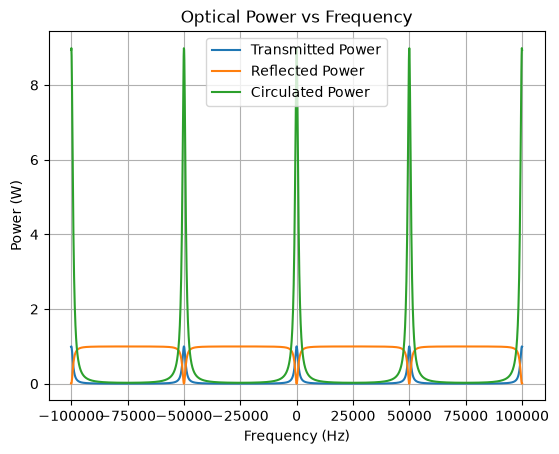

In [1]:
import finesse
from finesse import Model
from finesse.analysis.actions import Xaxis
import matplotlib.pyplot as plt

model = Model()
model.parse("""
l l0 P=1                # Laser with 1 W power
s s1 l0.p1 m1.p1 L=1    # Space between laser and mirror
m m1 R=0.9 T=0.1     # Mirror with r=0.99, t=0.01
s s2 m1.p2 m2.p1 L=3000 # Space between mirrors
m m2 R=0.9 T=0.1      # Mirror with r=0.99, t=0.01
            
pd trans m2.p2.o
pd refl m1.p1.o
pd circ m1.p2.i
""")

out = model.run(
    Xaxis(
        parameter='l0.f',
        mode='lin',
        start=-100e3,
        stop=100e3,
        steps=2000)
)

plt.plot(out.x[0], out['trans'], label='Transmitted Power')
plt.plot(out.x[0], out['refl'], label='Reflected Power')
plt.plot(out.x[0], out['circ'], label='Circulated Power')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (W)')
plt.title('Optical Power vs Frequency')
plt.legend()
plt.grid()
plt.show()

In [2]:
import numpy as np
c = 3e8                                                 # speed of light ( m / s )
L = 3000                                                # cavity length ( m )
R1 = 0.9; R2 = 0.9
FSR = c / (2 * L) # FSR
F = (np . pi * np . sqrt ( R1 * R2 ) ) / (1 - R1 * R2)  # Finesse
linewidth = FSR / F                                     # Linewidth

print(f"FSR: {FSR:.2f} Hz")
print(f"Finesse: {F:.2f}")
print(f"Linewidth: {linewidth:.2f} Hz")

FSR: 50000.00 Hz
Finesse: 14.88
Linewidth: 3359.94 Hz
